## Part 1. Loading Data
This first section initializes our environment by importing pandas for data manipulation and loading the raw ball-by-ball T20 cricket dataset into our script.

In [7]:
import pandas as pd

df = pd.read_csv('ball_by_ball_it20.csv')

if not df.empty:
    print("DataFrame loaded successfully!")
else:
    print("Loaded DataFrame is empty.")

DataFrame loaded successfully!


## Part 2: Exploratory Data Analysis (EDA)
Before changing any data, we explore it to understand its shape, check for missing values, and ensure our target variable (Wins vs. Losses for the chasing team) is balanced enough for an AI to learn from.

Total Rows and Columns: (425119, 35)

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 425119 entries, 0 to 425118
Data columns (total 35 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Unnamed: 0               425119 non-null  int64  
 1   Match ID                 425119 non-null  int64  
 2   Date                     425119 non-null  object 
 3   Venue                    425119 non-null  object 
 4   Bat First                425119 non-null  object 
 5   Bat Second               425119 non-null  object 
 6   Innings                  425119 non-null  int64  
 7   Over                     425119 non-null  int64  
 8   Ball                     425119 non-null  int64  
 9   Batter                   425119 non-null  object 
 10  Non Striker              425119 non-null  object 
 11  Bowler                   425119 non-null  object 
 12  Batter Runs              425119 non-null  int64  
 13  

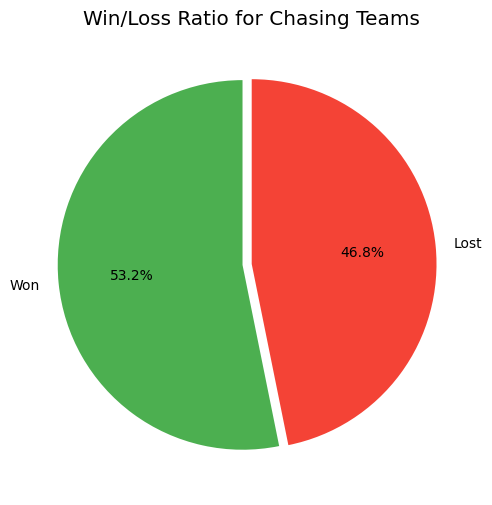

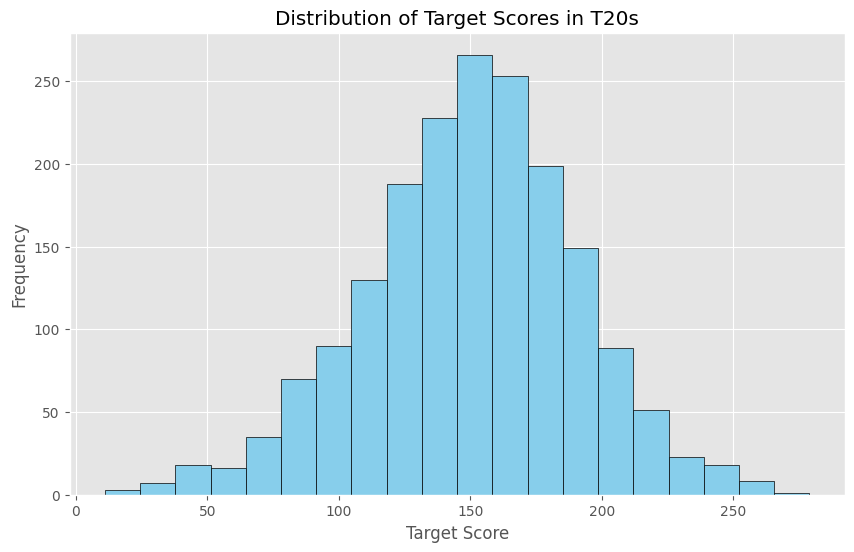

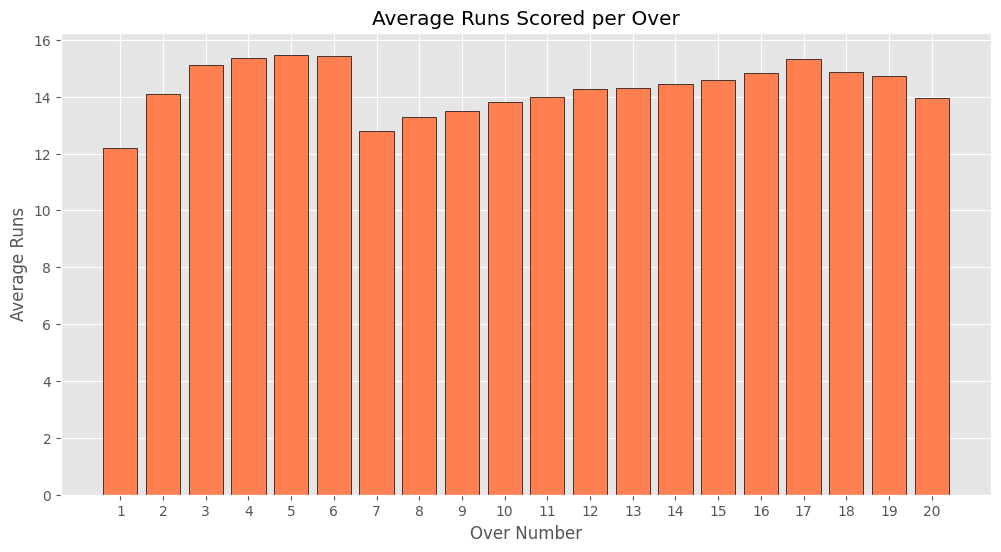

In [8]:
print(f"Total Rows and Columns: {df.shape}\n")

print("--- Dataset Info ---")
print(df.info())

chasing_team_data = df[df['Innings'] == 2]
win_loss_percentage = chasing_team_data['Chased Successfully'].value_counts(normalize=True) * 100
print("\n--- Win/Loss Percentage for Chasing Teams ---")
print(win_loss_percentage)

import matplotlib.pyplot as plt

plt.style.use('ggplot')

plt.figure(figsize=(8, 6))
win_loss = chasing_team_data['Chased Successfully'].value_counts()
plt.pie(win_loss, labels=['Won', 'Lost'], autopct='%1.1f%%', startangle=90, colors=['#4CAF50', '#F44336'], explode=(0.05, 0))
plt.title('Win/Loss Ratio for Chasing Teams')
plt.show()

plt.figure(figsize=(10, 6))
targets = chasing_team_data.drop_duplicates(subset=['Match ID'])['Target Score']
plt.hist(targets, bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Target Scores in T20s')
plt.xlabel('Target Score')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(12, 6))
runs_per_over = df.groupby('Over')['Runs From Ball'].sum() / df.groupby('Over')['Match ID'].nunique()
plt.bar(runs_per_over.index, runs_per_over.values, color='coral', edgecolor='black')
plt.title('Average Runs Scored per Over')
plt.xlabel('Over Number')
plt.ylabel('Average Runs')
plt.xticks(range(1, 21))
plt.show()

## Part 3: Feature Engineering (The Cricket Logic)
Raw ball-by-ball data isn't enough for the model; we need to calculate the broader context of the game. Here we use numpy to calculate real-time match metrics: Current Run Rate (CRR), Required Run Rate (RRR), and Wickets Left.

In [9]:
import numpy as np

chasing_df = df[df['Innings'] == 2].copy()

chasing_df['current_score'] = chasing_df['Innings Runs']
chasing_df['target'] = chasing_df['Target Score']
chasing_df['balls_left'] = chasing_df['Balls Remaining']

chasing_df['wickets_left'] = 10 - chasing_df['Innings Wickets']

overs_bowled = (120 - chasing_df['balls_left']) / 6
chasing_df['crr'] = np.where(overs_bowled == 0, 0, chasing_df['current_score'] / overs_bowled)

runs_left = chasing_df['target'] - chasing_df['current_score']
overs_left = chasing_df['balls_left'] / 6
chasing_df['rrr'] = np.where(overs_left == 0, 0, runs_left / overs_left)

chasing_df['result'] = chasing_df['Chased Successfully']

chasing_df.head(5)

,Unnamed: 0,Match ID,Date,Venue,Bat First,Bat Second,Innings,Over,Ball,Batter,...,Player Out Balls Faced,Bowler Runs Conceded,Valid Ball,current_score,target,balls_left,wickets_left,crr,rrr,result
124,124,1339605,2023-03-26,SuperSport Park,West Indies,South Africa,2,1,1,Q de Kock,...,NaN,4,1,4,259,119,10,24.0,12.857143,1
125,125,1339605,2023-03-26,SuperSport Park,West Indies,South Africa,2,1,2,Q de Kock,...,NaN,4,1,8,259,118,10,24.0,12.762712,1
126,126,1339605,2023-03-26,SuperSport Park,West Indies,South Africa,2,1,3,Q de Kock,...,NaN,0,1,8,259,117,10,16.0,12.871795,1
127,127,1339605,2023-03-26,SuperSport Park,West Indies,South Africa,2,1,4,Q de Kock,...,NaN,0,1,8,259,116,10,12.0,12.982759,1
128,128,1339605,2023-03-26,SuperSport Park,West Indies,South Africa,2,1,5,Q de Kock,...,NaN,1,1,9,259,115,10,10.8,13.043478,1


## Part 4: Data Cleaning and Splitting
Now that our features are built, we remove any rows with missing or broken data. Then, we use Scikit-Learn to divide the data: 80% to train the model, and 20% kept hidden to test its accuracy later.

In [10]:
from sklearn.model_selection import train_test_split

final_df = chasing_df[['target', 'current_score', 'balls_left', 'wickets_left', 'crr', 'rrr', 'result']].dropna()

final_df = final_df[(final_df['balls_left'] >= 0) & (final_df['wickets_left'] >= 0)]

X = final_df[['target', 'current_score', 'balls_left', 'wickets_left', 'crr', 'rrr']]
y = final_df['result']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data size: {X_train.shape[0]} balls")
print(f"Testing data size: {X_test.shape[0]} balls")

Training data size: 160240 balls
Testing data size: 40060 balls


## Part 5: Training the AI Model
We initialize a LogisticRegression model, which is perfect for this task because it calculates probabilities (percentages) rather than just giving a hard "Win" or "Loss". We train it on the 80% data, then test it on the 20% data.

In [11]:
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# 1. Scale the Data (CRITICAL FOR NEURAL NETWORKS)
# This forces all features to have a mean of 0 and a standard deviation of 1
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Build the Artificial Neural Network
model_ann = Sequential([
    # Hidden Layer 1: 16 neurons, ReLU activation stops negative outputs
    Dense(16, activation='relu', input_shape=(X_train.shape[1],)), 
    
    # Hidden Layer 2: 8 neurons to find deeper patterns
    Dense(8, activation='relu'),                                   
    
    # Output Layer: 1 neuron with Sigmoid to give us a clean percentage (0.0 to 1.0)
    Dense(1, activation='sigmoid')                                 
])

# 3. Compile the Model
# 'adam' is a fast optimizer, 'binary_crossentropy' is standard for Win/Loss predictions
model_ann.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 4. Train the Model
# epochs=20 means the AI will review the entire dataset 20 times to adjust its weights
print("Training the Neural Network...")
history = model_ann.fit(X_train_scaled, y_train, epochs=20, batch_size=32, validation_split=0.2, verbose=1)

# 5. Evaluate on the hidden Test Data
print("\n--- ANN EVALUATION ---")
loss, accuracy = model_ann.evaluate(X_test_scaled, y_test)
print(f"Deep Learning Accuracy: {accuracy * 100:.2f}%")


Training the Neural Network...
Epoch 1/20


c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4006/4006 ━━━━━━━━━━━━━━━━━━━━ 4s 993us/step - accuracy: 0.8178 - loss: 0.3928 - val_accuracy: 0.8262 - val_loss: 0.3738
Epoch 2/20
4006/4006 ━━━━━━━━━━━━━━━━━━━━ 4s 973us/step - accuracy: 0.8229 - loss: 0.3787 - val_accuracy: 0.8269 - val_loss: 0.3708
Epoch 3/20
4006/4006 ━━━━━━━━━━━━━━━━━━━━ 4s 998us/step - accuracy: 0.8237 - loss: 0.3771 - val_accuracy: 0.8265 - val_loss: 0.3706
Epoch 4/20
4006/4006 ━━━━━━━━━━━━━━━━━━━━ 4s 907us/step - accuracy: 0.8236 - loss: 0.3764 - val_accuracy: 0.8284 - val_loss: 0.3691
Epoch 5/20
4006/4006 ━━━━━━━━━━━━━━━━━━━━ 4s 946us/step - accuracy: 0.8249 - loss: 0.3758 - val_accuracy: 0.8278 - val_loss: 0.3693
Epoch 6/20
4006/4006 ━━━━━━━━━━━━━━━━━━━━ 4s 884us/step - accuracy: 0.8254 - loss: 0.3753 - val_accuracy: 0.8269 - val_loss: 0.3699
Epoch 7/20
4006/4006 ━━━━━━━━━━━━━━━━━━━━ 4s 950us/step - accuracy: 0.8258 - loss: 0.3749 - val_accuracy: 0.8284 - val_loss: 0.3673
Epoch 8/20
4006/4006 ━━━━━━━━━━━━━━━━━━━━ 4s 942us/step - accuracy: 0.8256 - loss: 0.37

## Part 6: Simulating a Live Match Prediction
The model is fully trained! This final block proves it works by simulating a live game. We feed the model a fake scenario, and it uses predict_proba to output the exact percentage chance the chasing team has of winning the match.

In [12]:
# 1. Define only the raw match variables
target_score = 185
current_score = 120
balls_left = 30
wickets_left = 6

# 2. Automatically calculate Overs, CRR, and RRR
overs_bowled = (120 - balls_left) / 6
overs_remaining = balls_left / 6

calculated_crr = current_score / overs_bowled if overs_bowled > 0 else 0
calculated_rrr = (target_score - current_score) / overs_remaining if overs_remaining > 0 else 0

# 3. Build the DataFrame using the automated calculations
test_scenario = pd.DataFrame({
    'target': [target_score],
    'current_score': [current_score],
    'balls_left': [balls_left], 
    'wickets_left': [wickets_left], 
    'crr': [calculated_crr],  
    'rrr': [calculated_rrr]  
})

# We MUST scale the live match data using the exact same scaler before predicting!
test_scenario_scaled = scaler.transform(test_scenario)

# Predict using the ANN
win_prob_ann = model_ann.predict(test_scenario_scaled)[0][0]

print("\n--- LIVE MATCH PREDICTION (NEURAL NETWORK) ---")
print(f"Scenario: Chasing {target_score}, Currently at {current_score}/{10 - wickets_left}")
print(f"Required Run Rate: {calculated_rrr:.2f}")
print(f"Win Probability for Chasing Team: {win_prob_ann * 100:.1f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step

--- LIVE MATCH PREDICTION (NEURAL NETWORK) ---
Scenario: Chasing 185, Currently at 120/4
Required Run Rate: 13.00
Win Probability for Chasing Team: 9.3%


## Part 7: Advanced Model Evaluation & Visual Metrics

This section imports advanced scoring tools from Scikit-Learn and uses seaborn and matplotlib to visually grade the model. It prints a detailed text report of precision and recall, plots a heatmap showing exactly where the model guessed right or wrong, and draws an ROC Curve to show the model's overall diagnostic ability.

1252/1252 ━━━━━━━━━━━━━━━━━━━━ 1s 403us/step
--- Detailed Classification Report ---
              precision    recall  f1-score   support

           0       0.84      0.85      0.84     21539
           1       0.82      0.81      0.81     18521

    accuracy                           0.83     40060
   macro avg       0.83      0.83      0.83     40060
weighted avg       0.83      0.83      0.83     40060

ROC-AUC Score: 0.9130



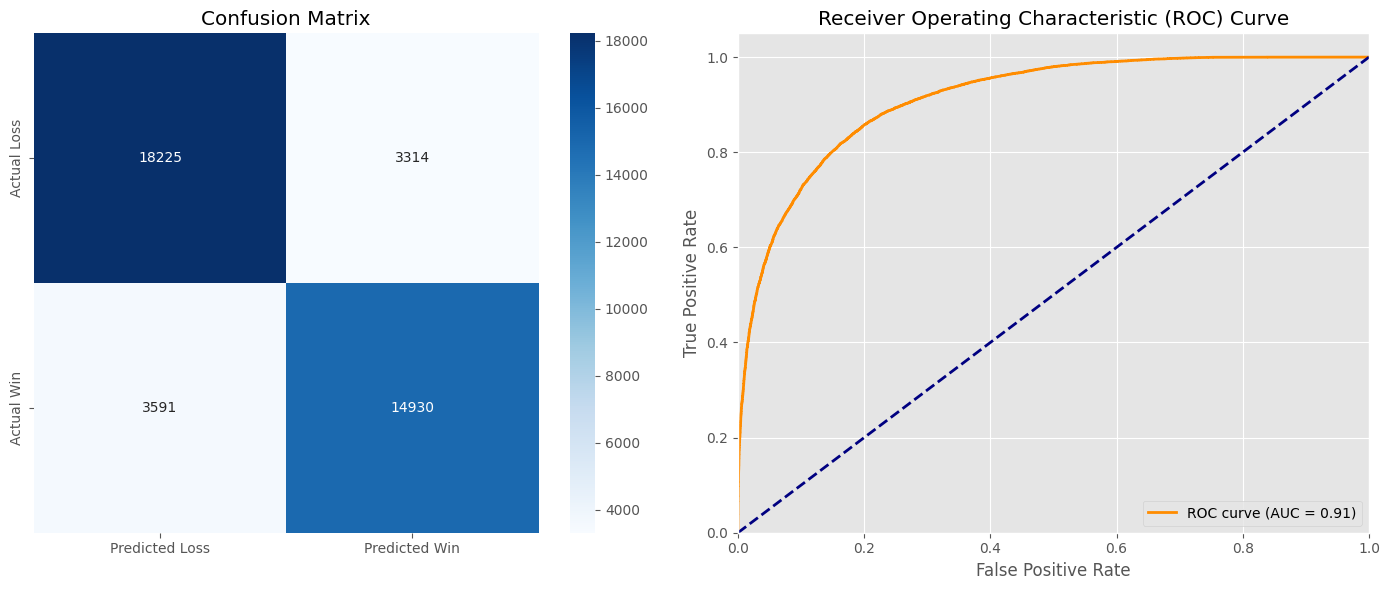

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score

# --- PART 6: EVALUATION ---

# 1. Scale the test data using the exact same scaler used during training
X_test_scaled = scaler.transform(X_test)

# 2. Get probabilities from the Keras ANN using the SCALED data
y_prob = model_ann.predict(X_test_scaled).ravel()

# 3. Convert probabilities to binary class predictions (0 or 1) using a 0.5 threshold
y_pred = (y_prob > 0.5).astype(int)

# 4. Print the classification report
print("--- Detailed Classification Report ---")
print(classification_report(y_test, y_pred))

# 5. Calculate the ROC AUC Score using the probabilities
auc_score = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC Score: {auc_score:.4f}\n")

# --- Plotting Code ---
plt.style.use('ggplot')
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], 
            xticklabels=['Predicted Loss', 'Predicted Win'], 
            yticklabels=['Actual Loss', 'Actual Win'])
axes[0].set_title('Confusion Matrix')

# Plot 2: ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.2f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Receiver Operating Characteristic (ROC) Curve')
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

## Part 8. Saving Model Weights

In [14]:
import pickle

# 1. Save the trained Keras Artificial Neural Network
model_ann.save('model_ann.keras')
print("Model saved successfully as 'model_ann.keras'")

# 2. Save the fitted StandardScaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("Scaler saved successfully as 'scaler.pkl'")

✅ Model saved successfully as 'model_ann.keras'
✅ Scaler saved successfully as 'scaler.pkl'
